# Federated Image Classification with ResNet-18 (Using FedProx)

In [1]:
!pip install torch torchvision -q

## Importing Required Libraries

This section imports the libraries required for building the Federated Learning pipeline.

The notebook mainly uses:

- PyTorch for deep learning
- Torchvision for datasets and transforms
- NumPy for numerical operations
- Matplotlib for plotting results

These libraries together help in model training, client simulation, and evaluation.

In [2]:

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.models import resnet18

from torch.utils.data import DataLoader, Subset

import numpy as np
import matplotlib.pyplot as plt
import time
import copy
import gc

## Configuring the Training Device

This cell checks whether CUDA is available.

If a GPU is detected, training is performed on the GPU; otherwise, the CPU is used.

Using a GPU significantly speeds up deep learning training, especially for convolutional neural networks like ResNet-18.

In [3]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", DEVICE)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Using Device: cuda
GPU: Tesla T4


## Defining Federated Learning Hyperparameters

This section defines the main training settings used throughout the experiment.

Some important parameters include:

- Number of clients
- Clients selected per round
- Number of communication rounds
- Local epochs
- Batch size
- Learning rate
- $\mu$ for FedProx


These values directly affect convergence speed, communication cost, and overall model performance.

In [30]:
NUM_CLIENTS = 20

CLIENTS_PER_ROUND = 4

ROUNDS = 25

LOCAL_EPOCHS = 1

BATCH_SIZE = 16

LEARNING_RATE = 0.0003

mu = 0.001

## Applying Image Transformations

Before training, the images are preprocessed using augmentation and normalization techniques.

The training data uses:

- Random cropping
- Horizontal flipping
- Normalization

These transformations help improve generalization and reduce overfitting.

---

## Normalization

Pixel values are normalized using:   $x' = \frac{x - \mu}{\sigma}$


where:

- $\mu$ is the dataset mean
- $\sigma$ is the standard deviation

In [5]:
transform_train = transforms.Compose([

    transforms.RandomCrop(32, padding=4),

    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

transform_test = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# Loading the CIFAR-100 Dataset

## What this code does
This cell downloads and loads:
- Training dataset
- Testing dataset

using the CIFAR-100 dataset from Torchvision.

## About CIFAR-100
CIFAR-100 contains:
- 60,000 color images
- 100 different classes
- 32×32 image size

## Dataset Split
- 50,000 training images
- 10,000 testing images

## Why this dataset is used
CIFAR-100 is commonly used for:
- Image classification research
- Federated Learning experiments
- Deep learning benchmarking

Its large number of classes makes the learning task more challenging.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
dataset_path = "/content/drive/MyDrive/FL_Project/datasets"

In [8]:


train_dataset = datasets.CIFAR100(
    root=dataset_path,
    train=True,
    download=False,
    transform=transform_train
)

test_dataset = datasets.CIFAR100(
    root=dataset_path,
    train=False,
    download=False,
    transform=transform_test
)

print("Training Samples:", len(train_dataset))

print("Testing Samples:", len(test_dataset))

Training Samples: 50000
Testing Samples: 10000


# Non-IID Client Data Distribution using Dirichlet Split

In real-world Federated Learning systems, client data is rarely Independent and Identically Distributed (IID). Different clients may contain different class distributions depending on user behavior, location, or device usage patterns.

To simulate this realistic scenario, we partition the CIFAR-100 dataset among clients using a Dirichlet distribution.

For each class, the sample proportions assigned to different clients are drawn from a Dirichlet distribution:

$$
(p_1, p_2, \dots, p_K) \sim \text{Dir}(\alpha)
$$

Where:
- $K$ is the number of clients
- $p_k$ represents the fraction of samples assigned to client $k$
- $\alpha$ controls the level of heterogeneity

### Effect of Alpha (\(\alpha\))

- Small $\alpha$ (e.g. 0.1):
  - Highly Non-IID distribution
  - Clients specialize in a few classes

- Large $\alpha$ (e.g. 10):
  - Nearly IID distribution
  - Class distributions become more uniform

In this experiment, Dirichlet partitioning creates realistic heterogeneous client datasets for Federated Learning training.

In [9]:
import numpy as np
from torch.utils.data import Subset

def create_dirichlet_noniid_clients(dataset, num_clients, alpha=0.5):

    labels = np.array(dataset.targets)
    num_classes = len(np.unique(labels))

    # Store indices for each client
    client_indices = [[] for _ in range(num_clients)]

    # Process each class separately
    for cls in range(num_classes):

        # Get all indices of current class
        cls_indices = np.where(labels == cls)[0]

        # Shuffle indices
        np.random.shuffle(cls_indices)

        # Generate Dirichlet proportions
        proportions = np.random.dirichlet(
            alpha=[alpha] * num_clients
        )

        # Convert proportions into split sizes
        split_sizes = (proportions * len(cls_indices)).astype(int)

        # Fix rounding issue
        split_sizes[-1] = len(cls_indices) - np.sum(split_sizes[:-1])

        # Split indices according to proportions
        split_indices = np.split(
            cls_indices,
            np.cumsum(split_sizes)[:-1]
        )

        # Assign to clients
        for client_id in range(num_clients):
            client_indices[client_id].extend(
                split_indices[client_id].tolist()
            )

    # Shuffle client data
    for client_id in range(num_clients):
        np.random.shuffle(client_indices[client_id])

    # Create PyTorch subsets
    client_datasets = [
        Subset(dataset, indices)
        for indices in client_indices
    ]

    return client_datasets

# Generating Federated Clients

## What this code does
This cell creates all client datasets using the previously defined Non-IID partitioning function.

## Output
- 20 simulated clients are created
- Each client contains a different subset of CIFAR-100 classes

## Why this is important
Federated Learning requires:
- Multiple decentralized clients
- Independent local datasets

This step simulates distributed user data.

In [10]:
client_datasets = create_dirichlet_noniid_clients(
    train_dataset,
    NUM_CLIENTS
)

print("\nCreated Non-IID Clients")


Created Non-IID Clients


In [11]:
from collections import Counter
import numpy as np

# CIFAR-100 class names
class_names = train_dataset.classes

for client_id, client_data in enumerate(client_datasets):

    # Get labels of samples in this client
    labels = [train_dataset.targets[idx] for idx in client_data.indices]

    # Count class occurrences
    class_count = Counter(labels)

    print(f"\nClient {client_id}")
    print("-" * 40)

    for cls, count in sorted(class_count.items()):

        print(f"{class_names[cls]:20s}: {count}")


Client 0
----------------------------------------
aquarium_fish       : 8
bear                : 17
beaver              : 5
bed                 : 40
bottle              : 27
bowl                : 6
boy                 : 73
bridge              : 16
bus                 : 39
can                 : 2
castle              : 24
caterpillar         : 1
chair               : 6
chimpanzee          : 1
clock               : 11
cloud               : 46
cockroach           : 48
couch               : 25
cup                 : 81
dinosaur            : 93
dolphin             : 4
flatfish            : 104
forest              : 22
fox                 : 51
girl                : 30
hamster             : 20
house               : 121
kangaroo            : 60
keyboard            : 3
lamp                : 7
lawn_mower          : 12
leopard             : 27
lion                : 44
lizard              : 11
lobster             : 3
man                 : 3
maple_tree          : 71
motorcycle          : 2
mountain  

# Initializing the Global ResNet-18 Model

This section initializes the global model used for Federated Learning.

The architecture used is ResNet-18, which introduces residual connections to improve deep network training.

---

## Residual Learning

Instead of learning a direct mapping, ResNet learns: $H(x) = F(x) + x$

where:

- $F(x)$ is the residual mapping
- $x$ is the shortcut connection

These skip connections help reduce the vanishing gradient problem in deep neural networks.

In [12]:
global_model = resnet18(
    num_classes=100
).to(DEVICE)

print("Global Model Initialized")

Global Model Initialized


# Client-Side Training using FedProx

The `train_client_fedprox()` function performs local training on each selected client using the FedProx optimization strategy. Similar to FedAvg, each client trains the received global model on its own local dataset. However, FedProx introduces an additional proximal regularization term to prevent the local model from drifting too far away from the global model.

This helps improve training stability in non-IID data settings, where client data distributions may differ significantly.

---

## Objective Function

In standard FedAvg, the client minimizes only the local classification loss:


FedProx modifies this objective by adding a proximal term:


Where:

- $F_k(w)$ is the local loss on client $k$
- $w^t$ represents the current global model weights
- $\mu$ is the proximal coefficient
- $\|w-w^t\|^2$ penalizes large deviations from the global model

---

## Training Procedure

The client-side training process consists of the following steps:

1. Receive the current global model from the server
2. Create a local copy of the model
3. Train the model on local client data
4. Compute:
   - Cross Entropy Loss
   - FedProx proximal regularization term
5. Update local model parameters using backpropagation
6. Return updated model weights to the server

---

## Loss Computation

The total training loss is computed as:



The Cross Entropy component helps the model learn the local classification task, while the proximal term restricts excessive divergence from the global model.

---

## Advantages of FedProx

- Improves stability in highly non-IID environments
- Reduces client drift during local optimization
- Handles heterogeneous client data distributions more effectively
- Maintains compatibility with standard FedAvg aggregation

---

## Implementation Details

- Optimizer: SGD with Momentum
- Loss Function: Cross Entropy Loss + Proximal Regularization
- Local Training: Multiple local epochs on client data
- Aggregation: Standard Federated Averaging at the server

The FedProx algorithm differs from FedAvg only in the local optimization objective; the server-side aggregation process remains unchanged.

In [27]:
def train_client_fedprox(
    model,
    global_model,
    client_dataset,
    epochs=LOCAL_EPOCHS,
    mu=mu
):

    model.train()

    trainloader = DataLoader(
        client_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=True
    )

    optimizer = optim.SGD(
        model.parameters(),
        lr=LEARNING_RATE,
        momentum=0.9
    )

    criterion = nn.CrossEntropyLoss()

    running_loss = 0.0

    for epoch in range(epochs):

        for images, labels in trainloader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(images)

            ce_loss = criterion(outputs, labels)

            # FedProx proximal term
            proximal_term = 0.0

            for param, global_param in zip(
                model.parameters(),
                global_model.parameters()
            ):
                proximal_term += torch.norm(
                    param - global_param,
                    p=2
                ) ** 2

            loss = ce_loss + (mu / 2) * proximal_term

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

    return model.state_dict(), running_loss

### Aggregating in Server

In [16]:
def federated_average(client_weights):

    global_dict = global_model.state_dict()

    for key in global_dict.keys():

        global_dict[key] = torch.stack([
            client_weights[i][key].float()
            for i in range(len(client_weights))
        ], dim=0).mean(dim=0)

    global_model.load_state_dict(global_dict)

    return global_model

## Evaluating the Global Model

This section evaluates the updated global model on the test dataset.

The performance is measured using classification accuracy.


## Accuracy Formula

$\text{Accuracy} =
\frac{\text{Correct Predictions}}
{\text{Total Samples}}
\times 100$

Higher accuracy indicates better generalization performance.

In [28]:
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

def evaluate_model(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    accuracy = 100 * correct / total

    return accuracy

### Federated Learning Training Process


In [31]:
round_accuracies = []
round_losses = []

best_accuracy = 0

best_model_weights = None

for round_num in range(ROUNDS):

    start_time = time.time()

    print("=" * 70)
    print(f"ROUND {round_num+1}/{ROUNDS}")
    print("=" * 70)

    selected_clients = np.random.choice(
        NUM_CLIENTS,
        CLIENTS_PER_ROUND,
        replace=False
    )

    print("Selected Clients:", selected_clients)

    client_weights = []
    client_losses = []

    for client_id in selected_clients:

        print(f"\nTraining Client {client_id}...")

        local_model = resnet18(
            num_classes=100
        ).to(DEVICE)

        local_model.load_state_dict(
            global_model.state_dict()
        )

        global_model_copy = copy.deepcopy(global_model)

        weights, loss = train_client_fedprox(
            local_model,
            global_model_copy,
            client_datasets[client_id]
        )

        client_weights.append(weights)
        client_losses.append(loss)

        print(
            f"Client {client_id} "
            f"Loss: {loss:.4f}"
        )

        del local_model

        torch.cuda.empty_cache()

        gc.collect()

    federated_average(client_weights)

    avg_loss = (
        sum(client_losses)
        / len(client_losses)
    )

    accuracy = evaluate_model(global_model)

    round_accuracies.append(accuracy)

    round_losses.append(avg_loss)

    if round_num == 0:
        accuracy_change = accuracy
    else:
        accuracy_change = (
            accuracy
            - round_accuracies[-2]
        )

    if accuracy > best_accuracy:

        best_accuracy = accuracy

        best_model_weights = copy.deepcopy(
            global_model.state_dict()
        )

    round_time = (
        time.time() - start_time
    )

    print("\n" + "=" * 70)
    print("ROUND SUMMARY")
    print("=" * 70)

    print(
        f"Average Client Loss : "
        f"{avg_loss:.4f}"
    )

    print(
        f"Global Accuracy     : "
        f"{accuracy:.2f}%"
    )

    print(
        f"Accuracy Change     : "
        f"{accuracy_change:+.2f}%"
    )

    print(
        f"Best Accuracy       : "
        f"{best_accuracy:.2f}%"
    )

    print(
        f"Round Duration      : "
        f"{round_time:.2f} sec"
    )

    print("=" * 70)
    print()

ROUND 1/25
Selected Clients: [19  9  5  2]

Training Client 19...
Client 19 Loss: 752.4100

Training Client 9...
Client 9 Loss: 487.9056

Training Client 5...
Client 5 Loss: 450.1682

Training Client 2...
Client 2 Loss: 391.6982

ROUND SUMMARY
Average Client Loss : 520.5455
Global Accuracy     : 15.44%
Accuracy Change     : +15.44%
Best Accuracy       : 15.44%
Round Duration      : 26.42 sec

ROUND 2/25
Selected Clients: [2 1 9 4]

Training Client 2...
Client 2 Loss: 385.4002

Training Client 1...
Client 1 Loss: 359.3947

Training Client 9...
Client 9 Loss: 472.4803

Training Client 4...
Client 4 Loss: 589.8714

ROUND SUMMARY
Average Client Loss : 451.7866
Global Accuracy     : 16.23%
Accuracy Change     : +0.79%
Best Accuracy       : 16.23%
Round Duration      : 22.98 sec

ROUND 3/25
Selected Clients: [ 2  8  0 17]

Training Client 2...
Client 2 Loss: 378.8162

Training Client 8...
Client 8 Loss: 433.7920

Training Client 0...
Client 0 Loss: 481.3307

Training Client 17...
Client 17 L

In [32]:
global_model.load_state_dict(
    best_model_weights
)

print("Best Model Restored")

print(
    f"Best Accuracy: "
    f"{best_accuracy:.2f}%"
)

Best Model Restored
Best Accuracy: 22.47%


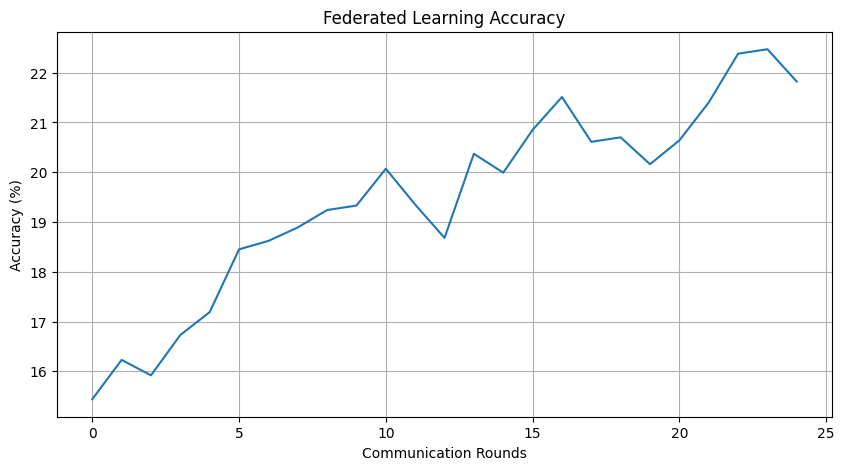

In [33]:
plt.figure(figsize=(10,5))

plt.plot(round_accuracies)

plt.xlabel("Communication Rounds")

plt.ylabel("Accuracy (%)")

plt.title(
    "Federated Learning Accuracy"
)

plt.grid(True)

plt.show()

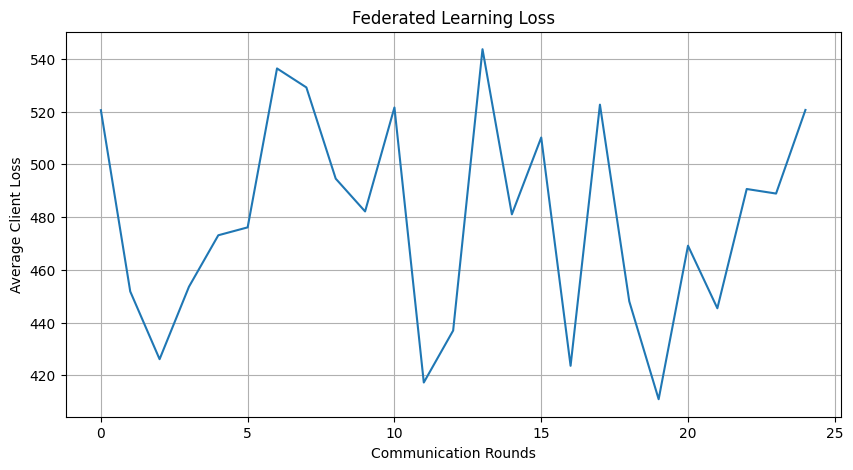

In [34]:
plt.figure(figsize=(10,5))

plt.plot(round_losses)

plt.xlabel("Communication Rounds")

plt.ylabel("Average Client Loss")

plt.title(
    "Federated Learning Loss"
)

plt.grid(True)

plt.show()

# Overall Conclusion

The FedProx-based federated learning experiment was successfully conducted using a ResNet-18 model on the CIFAR-100 dataset under a non-IID Dirichlet data distribution. Across 25 communication rounds, the global model demonstrated gradual improvement in classification performance while maintaining relatively stable convergence behavior.

The global accuracy increased from an initial value of **15.44%** in Round 1 to a best accuracy of **22.47%** by Round 24, indicating that the federated optimization process was able to effectively learn generalized representations from distributed client datasets despite strong data heterogeneity.

Although minor fluctuations in accuracy were observed across several communication rounds, the overall training trend showed progressive convergence. Such fluctuations are expected in federated learning environments with non-IID data distributions, where client updates may vary significantly depending on local class imbalance and client participation in each round.

The client losses also varied considerably between clients, particularly for certain participants such as Client 19, which consistently exhibited higher local losses throughout training. This behavior further confirms the heterogeneous nature of the distributed datasets and highlights the challenges associated with federated optimization under non-IID conditions.

The FedProx algorithm helped stabilize local optimization by incorporating a proximal regularization term into the client-side loss function. This proximal term constrained local model updates from deviating excessively from the global model, thereby reducing client drift and improving training robustness under heterogeneous data distributions.

Despite the improvement in stability, the final accuracy remained relatively moderate compared to centralized training scenarios. This is expected because federated learning introduces several additional challenges, including:
- decentralized optimization,
- partial client participation,
- communication constraints,
- and highly non-IID local datasets.

Overall, the experiment demonstrates that FedProx is an effective extension of FedAvg for federated learning in heterogeneous environments. While it may converge more conservatively due to the proximal constraint, it provides improved robustness and more stable optimization behavior when training across distributed non-IID client datasets.